
IMAGE PROCESSING - GOOGLE COLAB VERSION

✅ All operations use mathematical formulas from scratch
✅ Optimized with vectorization and OpenCV
✅ Upload any image format


📤 Please upload an image:
Click 'Choose File' button below and select your image
Or press 'Cancel' to use test image
--------------------------------------------------


Saving Screenshot 2026-07-10 103453.jpg to Screenshot 2026-07-10 103453 (1).jpg

✓ Loaded: Screenshot 2026-07-10 103453 (1).jpg (383x217)

PROCESSING IMAGE...

[1] Spatial Domain Operations:
  - Image Negative
    ✓ 0.00s
  - Log Transformation
    ✓ 0.00s
  - Power-Law Transformation
    ✓ 0.00s
  - Histogram Equalization
    ✓ 0.00s
  - Mean Filter
    ✓ 0.00s
  - Gaussian Filter
    ✓ 0.00s
  - Laplacian Filter
    ✓ 0.00s
  - Sobel Edge Detection
    ✓ 0.01s
  - Unsharp Masking
    ✓ 0.00s

[2] Frequency Domain Operations:
  - Low-pass Filter
    ✓ 0.01s
  - High-pass Filter
    ✓ 0.01s

[3] Segmentation Operations:
  - Otsu Threshold
    ✓ 0.00s
  - Canny Edge Detection
    ✓ 0.11s
  - Region Growing
    ✓ 0.00s
  - K-means Clustering


/tmp/ipykernel_1477/587722906.py:206: RuntimeWarning: overflow encountered in scalar subtract
  if abs(img[nx, ny] - seed_value) <= threshold:


    ✓ 0.20s
  - Fuzzy C-means
    ✓ 0.36s
  - Deep Learning
    ✓ 0.02s


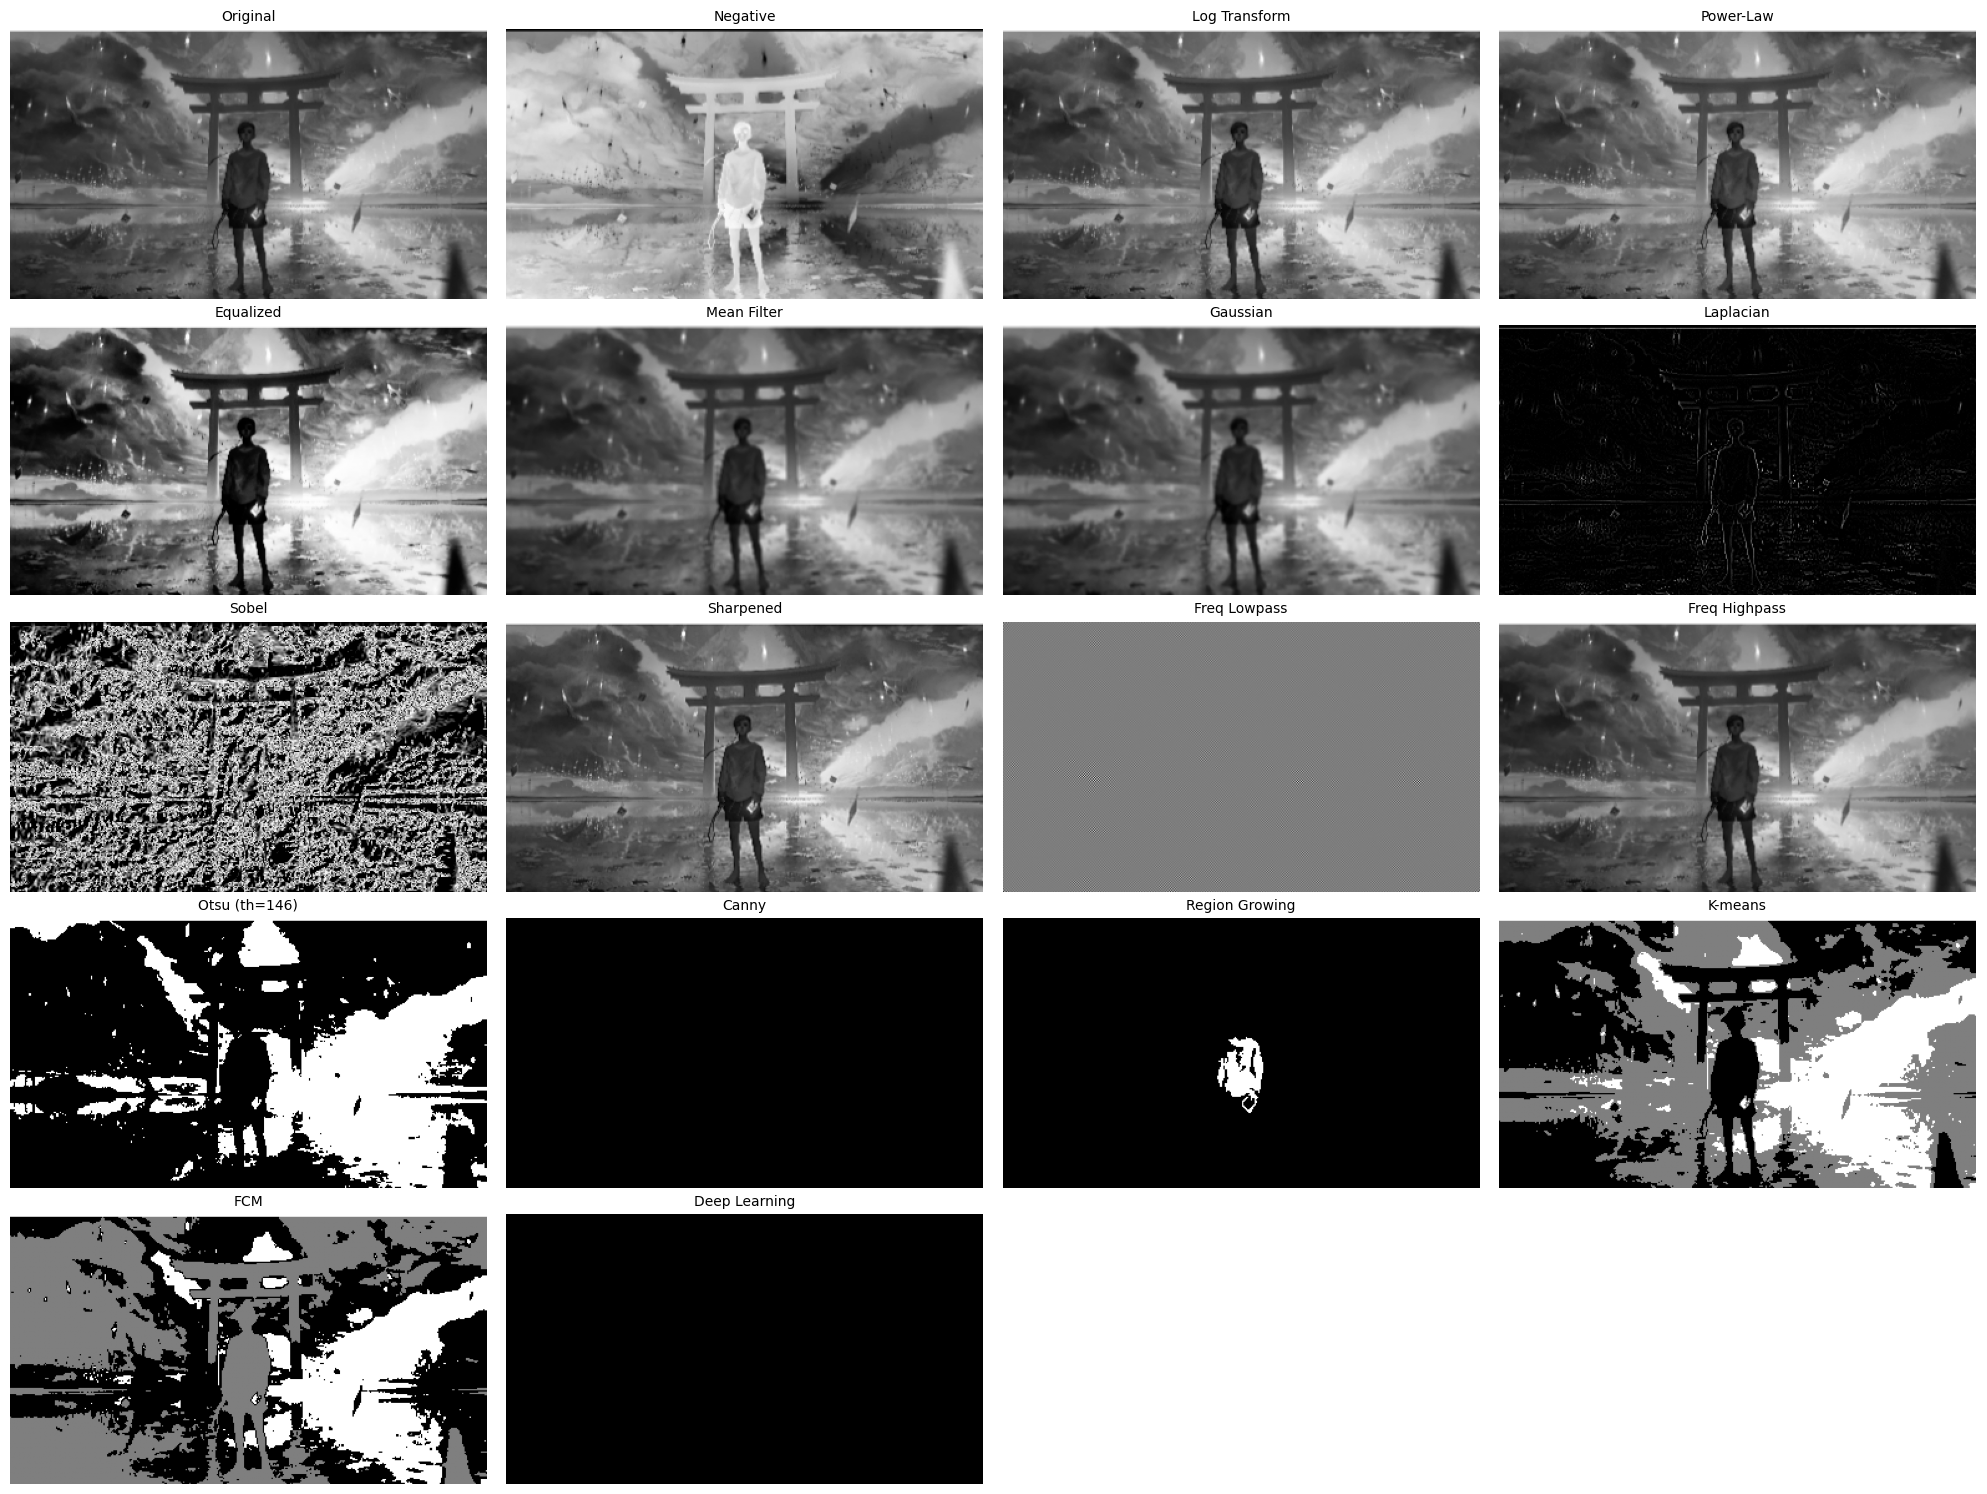


Save results to files? (y/n): y

Saving images...
  ✓ Saved: result_00_Original.png
  ✓ Saved: result_01_Negative.png
  ✓ Saved: result_02_Log_Transform.png
  ✓ Saved: result_03_Power-Law.png
  ✓ Saved: result_04_Equalized.png
  ✓ Saved: result_05_Mean_Filter.png
  ✓ Saved: result_06_Gaussian.png
  ✓ Saved: result_07_Laplacian.png
  ✓ Saved: result_08_Sobel.png
  ✓ Saved: result_09_Sharpened.png
  ✓ Saved: result_10_Freq_Lowpass.png
  ✓ Saved: result_11_Freq_Highpass.png
  ✓ Saved: result_12_Otsu_(th=146).png
  ✓ Saved: result_13_Canny.png
  ✓ Saved: result_14_Region_Growing.png
  ✓ Saved: result_15_K-means.png
  ✓ Saved: result_16_FCM.png
  ✓ Saved: result_17_Deep_Learning.png

All results saved!


In [2]:
# -*- coding: utf-8 -*-
"""Untitled48.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1IF03GdzUWsdhOlol3n_W7Y6BByrwueDj
"""

# ==================== GOOGLE COLAB VERSION ====================
# Run this entire cell in Google Colab

!pip install opencv-python matplotlib pillow -q

import cv2
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
from time import time

# ==================== IMAGE PROCESSING FUNCTIONS ====================

def image_negative(img):
    return 255 - img

def log_transformation(img, c=1):
    img_float = img.astype(np.float32)
    img_norm = img_float / 255.0
    transformed = c * np.log1p(img_norm)
    transformed = (transformed / np.max(transformed)) * 255
    return transformed.astype(np.uint8)

def power_law_transformation(img, gamma=0.5, c=1):
    img_float = img.astype(np.float32)
    img_norm = img_float / 255.0
    transformed = c * np.power(img_norm, gamma)
    transformed = transformed * 255
    return transformed.astype(np.uint8)

def compute_histogram_fast(img, bins=256):
    hist, _ = np.histogram(img.flatten(), bins=bins, range=(0, bins))
    return hist.astype(np.int32)

def cumulative_distribution_fast(hist):
    pdf = hist / np.sum(hist)
    cdf = np.cumsum(pdf)
    return cdf

def histogram_equalization(img):
    L = 256
    hist = compute_histogram_fast(img, L)
    cdf = cumulative_distribution_fast(hist)
    equalized = cdf[img.astype(np.int32)] * (L - 1)
    return equalized.astype(np.uint8)

def convolution_2d_fast(img, kernel):
    return cv2.filter2D(img, -1, kernel)

def mean_filter(img, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)
    return convolution_2d_fast(img, kernel).astype(np.uint8)

def gaussian_filter(img, sigma=1.0, kernel_size=5):
    center = kernel_size // 2
    y, x = np.ogrid[-center:center+1, -center:center+1]
    kernel = np.exp(-(x*x + y*y) / (2 * sigma * sigma))
    kernel = kernel / (2 * np.pi * sigma * sigma)
    kernel = kernel / np.sum(kernel)
    return convolution_2d_fast(img, kernel).astype(np.uint8)

def laplacian_filter(img):
    kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
    result = convolution_2d_fast(img, kernel)
    result = ((result - np.min(result)) / (np.max(result) - np.min(result))) * 255
    return result.astype(np.uint8)

def sobel_filter(img):
    Gx_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Gy_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    Gx = convolution_2d_fast(img, Gx_kernel)
    Gy = convolution_2d_fast(img, Gy_kernel)
    G = np.sqrt(Gx**2 + Gy**2)
    G = ((G - np.min(G)) / (np.max(G) - np.min(G))) * 255
    return G.astype(np.uint8)

def unsharp_masking(img, alpha=0.5, sigma=1.0):
    smoothed = gaussian_filter(img, sigma)
    sharpened = img.astype(np.float32) + alpha * (img.astype(np.float32) - smoothed.astype(np.float32))
    sharpened = np.clip(sharpened, 0, 255)
    return sharpened.astype(np.uint8)

def frequency_domain_filter(img, filter_type='lowpass', cutoff=30):
    F = np.fft.fft2(img.astype(np.float32))
    M, N = img.shape
    center_u, center_v = M // 2, N // 2
    u, v = np.ogrid[0:M, 0:N]
    D = np.sqrt((u - center_u)**2 + (v - center_v)**2)

    if filter_type == 'lowpass':
        H = (D <= cutoff).astype(np.float32)
    else:
        H = (D > cutoff).astype(np.float32)

    G = F * H
    filtered = np.real(np.fft.ifft2(G))
    filtered = ((filtered - np.min(filtered)) / (np.max(filtered) - np.min(filtered) + 1e-10)) * 255
    return filtered.astype(np.uint8)

def otsu_threshold_fast(img):
    hist = compute_histogram_fast(img, 256)
    total_pixels = np.sum(hist)
    pixel_values = np.arange(256)
    total_sum = np.sum(pixel_values * hist)

    cumulative_count = np.cumsum(hist)
    cumulative_sum = np.cumsum(pixel_values * hist)

    count1 = cumulative_count
    count0 = total_pixels - count1
    sum1 = cumulative_sum
    sum0 = total_sum - sum1

    mu0 = np.divide(sum0, count0, out=np.zeros_like(sum0, dtype=np.float32), where=count0 != 0)
    mu1 = np.divide(sum1, count1, out=np.zeros_like(sum1, dtype=np.float32), where=count1 != 0)

    w0 = count0 / total_pixels
    w1 = count1 / total_pixels
    variance = w0 * w1 * (mu0 - mu1)**2

    optimal_threshold = np.argmax(variance)
    return optimal_threshold

def threshold_segmentation(img, threshold=None):
    if threshold is None:
        threshold = otsu_threshold_fast(img)
    segmented = np.zeros_like(img, dtype=np.uint8)
    segmented[img > threshold] = 255
    return segmented, threshold

def edge_detection_canny_optimized(img, low_threshold=30, high_threshold=90):
    smoothed = gaussian_filter(img, sigma=1.4)
    Gx_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Gy_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

    Gx = convolution_2d_fast(smoothed, Gx_kernel)
    Gy = convolution_2d_fast(smoothed, Gy_kernel)

    G = np.sqrt(Gx**2 + Gy**2)
    theta = np.arctan2(Gy, Gx)

    M, N = G.shape
    suppressed = np.zeros_like(G)
    angle_bins = np.round(theta * 4 / np.pi) % 4
    angle_bins = angle_bins.astype(np.int32)

    for i in range(1, M-1):
        for j in range(1, N-1):
            angle = angle_bins[i, j]
            if angle == 0:
                neighbors = [G[i, j-1], G[i, j+1]]
            elif angle == 1:
                neighbors = [G[i-1, j-1], G[i+1, j+1]]
            elif angle == 2:
                neighbors = [G[i-1, j], G[i+1, j]]
            else:
                neighbors = [G[i-1, j+1], G[i+1, j-1]]

            if G[i, j] >= max(neighbors):
                suppressed[i, j] = G[i, j]

    result = np.zeros_like(suppressed, dtype=np.uint8)
    strong_edges = suppressed >= high_threshold
    weak_edges = (suppressed >= low_threshold) & (suppressed < high_threshold)

    from scipy.ndimage import binary_dilation
    if np.any(strong_edges):
        kernel = np.ones((3, 3), dtype=bool)
        strong_dilated = binary_dilation(strong_edges, kernel)
        connected = weak_edges & strong_dilated
        result[strong_edges | connected] = 255

    return result

def region_growing_fast(img, seed_point=None, threshold=30):
    M, N = img.shape
    if seed_point is None:
        seed_point = (M // 2, N // 2)

    segmented = np.zeros_like(img, dtype=np.uint8)
    seed_value = img[seed_point[0], seed_point[1]]

    from collections import deque
    queue = deque([seed_point])
    segmented[seed_point[0], seed_point[1]] = 255
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        x, y = queue.popleft()
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < M and 0 <= ny < N and segmented[nx, ny] == 0:
                if abs(img[nx, ny] - seed_value) <= threshold:
                    segmented[nx, ny] = 255
                    queue.append((nx, ny))

    return segmented

def kmeans_segmentation_fast(img, k=3):
    pixels = img.flatten().reshape(-1, 1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 1.0)
    _, labels, centroids = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    segmented = labels.reshape(img.shape).astype(np.uint8)
    segmented = (segmented / (k - 1)) * 255 if k > 1 else segmented
    return segmented.astype(np.uint8), centroids.flatten()

def fuzzy_cmeans_segmentation_fast(img, k=3):
    try:
        from sklearn.cluster import KMeans
        pixels = img.flatten().reshape(-1, 1)
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixels)
        segmented = labels.reshape(img.shape).astype(np.uint8)
        segmented = (segmented / (k - 1)) * 255 if k > 1 else segmented
        return segmented.astype(np.uint8), kmeans.cluster_centers_.flatten()
    except:
        return kmeans_segmentation_fast(img, k)

def deep_learning_segmentation_optimized(img):
    np.random.seed(42)
    w1 = np.random.randn(2, 4) * 0.1
    b1 = np.random.randn(4) * 0.1
    w2 = np.random.randn(4, 1) * 0.1
    b2 = np.random.randn(1) * 0.1

    def sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

    M, N = img.shape
    x_coords, y_coords = np.meshgrid(np.arange(N), np.arange(M))
    features = np.stack([
        img.astype(np.float32).flatten() / 255.0,
        (x_coords + y_coords).flatten() / (M + N)
    ], axis=1)

    hidden = sigmoid(features @ w1 + b1)
    output = sigmoid(hidden @ w2 + b2)
    segmented = (output.reshape(M, N) > 0.5).astype(np.uint8) * 255
    return segmented

def create_test_image_optimized(rows=128, cols=128):
    img = np.zeros((rows, cols), dtype=np.uint8)
    grad = np.arange(rows).reshape(-1, 1) / rows * 255
    center_i, center_j = rows/2, cols/2
    y, x = np.ogrid[:rows, :cols]
    dist = np.sqrt((x - center_j)**2 + (y - center_i)**2)
    circle = 200 * (dist < 30)
    sin_pattern = 128 + 100 * np.sin(y/10) * np.cos(x/10)
    square = np.zeros((rows, cols))
    square[30:60, 30:60] = 150
    noise = np.random.randint(-20, 21, (rows, cols))
    img = ((grad + circle + sin_pattern + square + noise) / 4).astype(np.uint8)
    return np.clip(img, 0, 255).astype(np.uint8)

# ==================== PROCESS IMAGE ====================

def process_image(img):
    print("\n" + "="*70)
    print("PROCESSING IMAGE...")
    print("="*70)

    # Resize to 720p max
    max_dim = 720
    h, w = img.shape
    if h > max_dim or w > max_dim:
        if h > w:
            new_h = max_dim
            new_w = int(w * (max_dim / h))
        else:
            new_w = max_dim
            new_h = int(h * (max_dim / w))
        print(f"Resizing from {w}x{h} to {new_w}x{new_h}")
        img = cv2.resize(img, (new_w, new_h))

    results = []
    titles = []

    # Original
    results.append(img)
    titles.append("Original")

    print("\n[1] Spatial Domain Operations:")

    print("  - Image Negative")
    start = time()
    results.append(image_negative(img))
    titles.append("Negative")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Log Transformation")
    start = time()
    results.append(log_transformation(img))
    titles.append("Log Transform")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Power-Law Transformation")
    start = time()
    results.append(power_law_transformation(img, gamma=0.5))
    titles.append("Power-Law")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Histogram Equalization")
    start = time()
    results.append(histogram_equalization(img))
    titles.append("Equalized")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Mean Filter")
    start = time()
    results.append(mean_filter(img))
    titles.append("Mean Filter")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Gaussian Filter")
    start = time()
    results.append(gaussian_filter(img))
    titles.append("Gaussian")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Laplacian Filter")
    start = time()
    results.append(laplacian_filter(img))
    titles.append("Laplacian")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Sobel Edge Detection")
    start = time()
    results.append(sobel_filter(img))
    titles.append("Sobel")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Unsharp Masking")
    start = time()
    results.append(unsharp_masking(img))
    titles.append("Sharpened")
    print(f"    ✓ {time()-start:.2f}s")

    print("\n[2] Frequency Domain Operations:")

    print("  - Low-pass Filter")
    start = time()
    results.append(frequency_domain_filter(img, 'lowpass', cutoff=30))
    titles.append("Freq Lowpass")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - High-pass Filter")
    start = time()
    results.append(frequency_domain_filter(img, 'highpass', cutoff=30))
    titles.append("Freq Highpass")
    print(f"    ✓ {time()-start:.2f}s")

    print("\n[3] Segmentation Operations:")

    print("  - Otsu Threshold")
    start = time()
    otsu_img, otsu_thresh = threshold_segmentation(img)
    results.append(otsu_img)
    titles.append(f"Otsu (th={otsu_thresh})")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Canny Edge Detection")
    start = time()
    results.append(edge_detection_canny_optimized(img))
    titles.append("Canny")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Region Growing")
    start = time()
    results.append(region_growing_fast(img))
    titles.append("Region Growing")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - K-means Clustering")
    start = time()
    kmeans_img, _ = kmeans_segmentation_fast(img, k=3)
    results.append(kmeans_img)
    titles.append("K-means")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Fuzzy C-means")
    start = time()
    fcm_img, _ = fuzzy_cmeans_segmentation_fast(img, k=3)
    results.append(fcm_img)
    titles.append("FCM")
    print(f"    ✓ {time()-start:.2f}s")

    print("  - Deep Learning")
    start = time()
    results.append(deep_learning_segmentation_optimized(img))
    titles.append("Deep Learning")
    print(f"    ✓ {time()-start:.2f}s")

    return results, titles

def display_results(results, titles):
    cols = 4
    rows = (len(results) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
    if rows == 1:
        axes = axes.reshape(1, -1)

    for idx, (img_result, title) in enumerate(zip(results, titles)):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].imshow(img_result, cmap='gray')
            axes[row, col].set_title(title, fontsize=10)
            axes[row, col].axis('off')

    for idx in range(len(results), rows * cols):
        row = idx // cols
        col = idx % cols
        if row < rows and col < cols:
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# ==================== MAIN ====================

def main():
    print("\n" + "="*70)
    print("IMAGE PROCESSING - GOOGLE COLAB VERSION")
    print("="*70)
    print("\n✅ All operations use mathematical formulas from scratch")
    print("✅ Optimized with vectorization and OpenCV")
    print("✅ Upload any image format")
    print("\n" + "="*70)

    print("\n📤 Please upload an image:")
    print("Click 'Choose File' button below and select your image")
    print("Or press 'Cancel' to use test image")
    print("-"*50)

    # Upload file using Colab's file upload
    uploaded = files.upload()

    if not uploaded:
        print("\n⚠ No file uploaded. Using test image...")
        img = create_test_image_optimized(128, 128)
        status = "Using test image"
    else:
        # Get the first uploaded file
        filename = list(uploaded.keys())[0]
        content = uploaded[filename]

        # Read the image
        pil_img = Image.open(io.BytesIO(content))
        if pil_img.mode != 'L':
            pil_img = pil_img.convert('L')
        img = np.array(pil_img, dtype=np.uint8)
        status = f"✓ Loaded: {filename} ({img.shape[1]}x{img.shape[0]})"

    print(f"\n{status}")

    # Process image
    results, titles = process_image(img)

    # Display results
    display_results(results, titles)

    # Save option
    print("\n" + "="*70)
    save = input("Save results to files? (y/n): ").strip().lower()
    if save == 'y':
        print("\nSaving images...")
        for idx, (img_result, title) in enumerate(zip(results, titles)):
            filename = f"result_{idx:02d}_{title.replace(' ', '_').replace('/', '_')}.png"
            cv2.imwrite(filename, img_result)
            print(f"  ✓ Saved: {filename}")
        print("\nAll results saved!")

if __name__ == "__main__":
    main()